# Linear Regression and Correlation *(Instructor — solutions filled in)*


**Estimated Time**: 25-30 Minutes  
**Professor**: Elizabeth Schwartz </br>
**Developers**: Rinrada Maneenop  </br>
**Textbook Reference**: OpenStax *Introductory Statistics 2e*, Chapter 12 (Linear Regression and Correlation)  
**Goal**: Learn the basics of scatter plots, correlation, and simple linear regression with guided practice.

## Table of Contents

1. Quick Concepts and Setup  
2. Load and View the Data  
3. Scatter Plot (Always Start Here)  
4. Correlation Coefficient `r`  
5. Regression Line `y_hat = a + bx`  
6. Prediction and Caution About Extrapolation  
7. Short Practice Exercises

## Notebook Structure

You will see short **example -> practice** cycles.

This **instructor** notebook includes **completed code** everywhere the student version used `...`. For distribution, use `linear_regression.ipynb` and keep this file private.
Run cells top to bottom to verify output on your machine.

This notebook follows OpenStax Ch. 12 guidance:
- start with a scatter plot,
- use `r` to describe strength/direction,
- use the regression line for prediction only when linear and within the observed x-range.

---

## 1. Introduction

### 1.1. Learning Objectives

Do NBA players who score more points earn higher salaries? Are there other stats that might predict pay even better? In this notebook, we'll use **real NBA player data** to explore these questions using the tools of **linear regression and correlation**. By the end, you will:

- Understand what a **scatter plot** tells us about the relationship between two variables
- Measure the strength of a linear relationship using the **correlation coefficient *r***
- Calculate and interpret a **regression line** (line of best fit)
- Use the regression line to make **predictions**
- Apply these skills to explore a relationship of your own choosing in the sandbox

### 1.2. What is Linear Regression?

Suppose you want to predict an NBA player's salary based on how many points they score per game. You have data on hundreds of players, but there's no perfect rule — a player who scores 20 points a game doesn't always earn exactly twice as much as one who scores 10. Instead, the data follows a **trend**.

**Linear Regression** is a method that finds the straight line that best describes this trend. The line has the form:

> **ŷ = a + b · x**

Where:
- **x** is the *independent variable* (the input — e.g., points per game)
- **ŷ** ("y-hat") is the *predicted value* of the *dependent variable* (the output — e.g., salary)
- **b** is the *slope* — how much ŷ changes for each 1-unit increase in x
- **a** is the *y-intercept* — the value of ŷ when x equals 0

Before fitting a line, we also measure **correlation** — a number between -1 and 1 that describes how strongly and in which direction two variables move together.

### 1.3. Setup

Below, we have imported the Python libraries needed for this module. Run the code in this cell before running any other code cells, and be careful **not to change** any of the code.

You can run the cell in any of these ways:
- **Ctrl + Enter**: Run the cell and keep the cursor in the same cell.
- **Shift + Enter**: Run the cell and move the cursor to the next cell.
- **Click the Play button**: Click the Run (play) button to the left of the cell to execute it.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from visuals import (
    show_interactive_correlation,
    show_interactive_line_tuner,
    show_prediction_slider,
    show_sandbox_regression,
)

# Make plots look clean
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

---

## 2. Data Preparation

### 2.1. Loading the Data

We will work with an **NBA player dataset** from the Data 8 Spring 2025 course materials. It contains statistics and salary information for NBA players across a season. Let's load it and take a first look!

In [2]:
# Load the dataset from the Data 8 SP25 review sandbox
url = "https://raw.githubusercontent.com/data-8/materials-sp25/main/review-sandbox/nba.csv"
nba = pd.read_csv(url)

# Display the first 10 rows
display(nba.head(10))
print(f"Shape: {nba.shape[0]} rows x {nba.shape[1]} columns")
print(f"Columns: {list(nba.columns)}")

,Player,Salary Rank,Salary,Player Rank,Age,Team,Position,Games,Rebounds,Assists,Steals,Blocks,Turnovers,Points
0,Stephen Curry,1,51915615,11,35,GSW,PG,74,4.5,5.1,0.7,0.4,2.8,26.4
1,Kevin Durant,2,47649433,7,35,PHO,PF,75,6.6,5.0,0.9,1.2,3.3,27.1
2,Joel Embiid,3,47607350,1,29,PHI,C,39,11.0,5.6,1.2,1.7,3.8,34.7
3,LeBron James,3,47607350,15,39,LAL,PF,71,7.3,8.3,1.3,0.5,3.5,25.7
4,Bradley Beal,6,46741590,63,30,PHO,SG,53,4.4,5.0,1.0,0.5,2.5,18.2
5,Damian Lillard,7,45640084,20,33,MIL,PG,73,4.4,7.0,1.0,0.2,2.6,24.3
6,Giannis Antetokounmpo,7,45640084,3,29,MIL,PF,73,11.5,6.5,1.2,1.1,3.4,30.4
7,Kawhi Leonard,7,45640084,25,32,LAC,SF,68,6.1,3.6,1.6,0.9,1.8,23.7
8,Paul George,7,45640084,31,33,LAC,PF,74,5.2,3.5,1.5,0.5,2.1,22.6
9,Jimmy Butler,11,45183960,44,34,MIA,PF,60,5.3,5.0,1.3,0.3,1.7,20.8


Shape: 525 rows x 14 columns
Columns: ['Player', 'Salary Rank', 'Salary', 'Player Rank', 'Age', 'Team', 'Position', 'Games', 'Rebounds', 'Assists', 'Steals', 'Blocks', 'Turnovers', 'Points']


### 2.2. Exploring the Data

Before we do any analysis, let's get a feel for the numbers. The cell below prints summary statistics — the mean, standard deviation, minimum, and maximum — for all numeric columns.

In [3]:
# Summary statistics for numeric columns
display(nba.describe().round(2))

,Salary Rank,Salary,Player Rank,Age,Games,Rebounds,Assists,Steals,Blocks,Turnovers,Points
count,525.00,525.00,525.00,525.00,525.00,525.00,525.00,525.00,525.00,525.00,525.00
mean,294.06,8450354.60,286.46,25.74,43.37,3.37,2.02,0.61,0.40,0.98,8.49
std,171.74,10939982.45,164.46,4.21,26.23,2.37,1.87,0.40,0.41,0.81,6.84
min,1.00,35389.00,1.00,19.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,149.00,1719864.00,146.00,23.00,18.00,1.70,0.70,0.30,0.10,0.40,3.40
50%,290.00,3536280.00,289.00,25.00,46.00,3.00,1.30,0.60,0.30,0.70,6.50
75%,439.00,10880364.00,427.00,28.00,68.00,4.50,2.80,0.90,0.60,1.40,12.20
max,612.00,51915615.00,570.00,39.00,82.00,13.70,10.90,2.10,3.60,4.40,34.70


**Question 2.2.** Look at the summary statistics for `Salary`. What is the average salary? What is the range (min to max)? Does the spread surprise you — and why or why not?

*Your Answer Here*

### 2.3. Cleaning the Data

Real-world data often has missing values. Let's check whether any rows are missing `Salary` or `Points`, and drop those rows so our analysis is based on complete records only.

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/data-8/materials-sp25/main/review-sandbox/nba.csv"
nba = pd.read_csv(url)

print("Missing values per column:")
print(nba.isnull().sum())
print()

nba_clean = nba.dropna(subset=["Salary", "Points"]).copy()
print(f"Rows before cleaning: {len(nba)}")
print(f"Rows after cleaning:  {len(nba_clean)}")

Missing values per column:
Player         0
Salary Rank    0
Salary         0
Player Rank    0
Age            0
Team           0
Position       0
Games          0
Rebounds       0
Assists        0
Steals         0
Blocks         0
Turnovers      0
Points         0
dtype: int64

Rows before cleaning: 525
Rows after cleaning:  525


**Question 2.3.** Why is it important to remove rows with missing `Salary` or `Points` values before fitting a regression line? What might happen to our analysis if we left them in?

*Your Answer Here*

---

## 3. Visualizing the Data

### 3.1. Scatter Plots

A **scatter plot** is always the first step when studying the relationship between two numerical variables. For correlation and regression we use **`Age` (years) vs `Games` (games played)** — a **weak but real** linear link whose **p-value prints as an ordinary decimal** (unlike `Points` vs `Salary`, where \(r\) is so strong that the p-value is essentially 0 in scientific notation). Each dot is one player.

When looking at a scatter plot, ask yourself:
- Does the cloud of points slope **upward** (positive), **downward** (negative), or show **no pattern** (no relationship)?
- How tightly **clustered** are the points around an imaginary line?
- Are there any **outliers** that sit far from the rest?

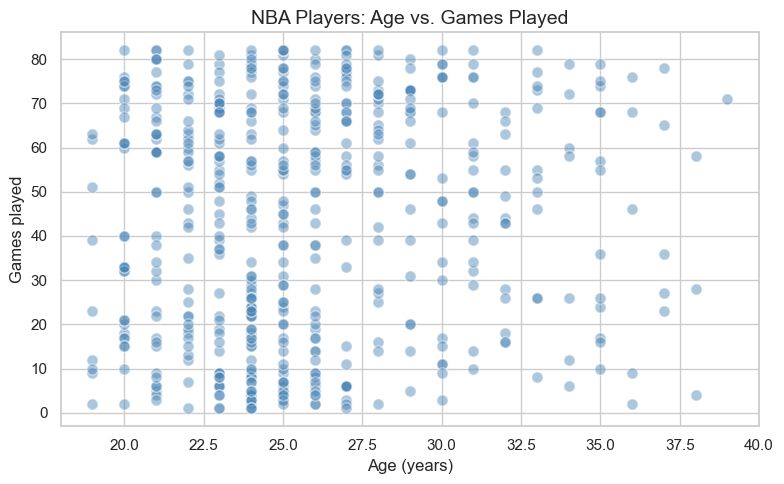

In [5]:
fig, ax = plt.subplots()

ax.scatter(nba_clean["Age"], nba_clean["Games"],
           alpha=0.45, color="steelblue", edgecolors="white", s=65)

ax.set_xlabel("Age (years)", fontsize=12)
ax.set_ylabel("Games played", fontsize=12)
ax.set_title("NBA Players: Age vs. Games Played", fontsize=14)

plt.tight_layout()
plt.show()

**Question 3.1.** Describe what you see in the scatter plot. Is there a clear direction to the relationship? Does it look linear? Would you say the relationship is strong or weak — and why?

*Your Answer Here*

**Question 3.2.** Do you notice any outliers — players who seem to earn much more than their scoring average would predict? What might explain why a player commands a very high salary without being a top scorer?

*Your Answer Here*

---

## 4. The Correlation Coefficient

### 4.1. What Does *r* Tell Us?

The **correlation coefficient**, written as ***r***, is a single number between **-1 and +1** that captures the strength and direction of the linear relationship between two variables.

| Value of *r* | Interpretation |
|---|---|
| Close to **+1** | Strong **positive** relationship — as x increases, y tends to increase |
| Close to **-1** | Strong **negative** relationship — as x increases, y tends to decrease |
| Close to **0** | Little to no linear relationship |
| Exactly **+1** or **-1** | Perfect linear relationship (all points on one line) |

Use the interactive visual below to build intuition:
- Move the `Target r` slider to change direction/strength.
- Click **Generate New Sample** to see that random samples vary, even with the same target correlation.

In [ ]:
show_interactive_correlation()

### 4.2. Computing *r*

Now let's compute *r* for **`Age` vs `Games`**. We'll use software to get both *r* and a **p-value**. The p-value tells us whether the correlation is statistically significant — i.e., whether it's unlikely to have occurred by random chance alone. A p-value below 0.05 is typically considered significant. (Here \(r\) is modest and **p** is on the order of **0.04** — easy to read — not astronomically small like for `Points` vs `Salary`.)

In [7]:
x = nba_clean["Age"]
y = nba_clean["Games"]

r, p_value = stats.pearsonr(x, y)

print(f"Correlation coefficient (r): {r:.4f}")
print(f"p-value:                     {p_value:.4f}")

Correlation coefficient (r): 0.0880
p-value:                     0.0440


**Question 4.1 (Code Practice — instructor solution).** The next code cell shows the completed answer for extracting and interpreting the correlation for `Age` vs `Games`.

In [8]:
# Instructor solution: interpret the correlation result
r_value = r  # use the value already computed above

if r_value > 0:
    direction = "positive"
else:
    direction = "negative"

print(f"r = {r_value:.3f}")
print(f"Direction: {direction}")


r = 0.088
Direction: positive


**Question 4.2 (Code Practice — instructor solution).** The next code cell shows the completed significance test at `alpha = 0.05`.

In [9]:
# Instructor solution: significance at alpha = 0.05
alpha = 0.05
is_significant = p_value < alpha

print(f"p-value = {p_value:.4f}")
print(f"Significant at alpha={alpha}? {is_significant}")

if is_significant:
    print("There is evidence of a linear relationship between Age and games played.")
else:
    print("There is not enough evidence of a linear relationship.")


p-value = 0.0440
Significant at alpha=0.05? True
There is evidence of a linear relationship between Age and games played.


---

## 5. The Regression Line

### 5.1. Slope and Intercept

Since the correlation is **positive and statistically significant** at conventional levels (even though \(r\) is modest), we can fit a **regression line** — the single straight line that minimizes the total squared distance between itself and all the data points. This is called the **Least Squares Regression Line**.

The formulas for slope and intercept are:

$$
b = r\left(\frac{s_y}{s_x}\right)
$$

- $b$: slope of the regression line (how much predicted **games played** changes for **+1 year of age**)
- $r$: correlation coefficient between $x$ and $y$
- $s_y$: standard deviation of $y$ (here, `Games`)
- $s_x$: standard deviation of $x$ (here, `Age`)

$$
a = \bar{y} - b\bar{x}
$$

- $a$: intercept of the regression line (predicted games when age = 0 — not meaningful in real life, but part of the math)
- $\bar{y}$: mean of $y$
- $\bar{x}$: mean of $x$
- $x$: observed value of the independent variable
- $\hat{y}$: predicted value from the regression line

Let's compute these step by step using the Chapter 12 formulas.

In [10]:
# Step 1: Compute means and standard deviations
x_mean, y_mean = x.mean(), y.mean()
x_std,  y_std  = x.std(),  y.std()

print(f"Mean Age   : {x_mean:.3f} years")
print(f"Mean Games : {y_mean:.3f}")
print(f"Std  Age   : {x_std:.3f}")
print(f"Std  Games : {y_std:.3f}")

Mean Age   : 25.737 years
Mean Games : 43.370
Std  Age   : 4.205
Std  Games : 26.226


In [11]:
# Step 2: Compute slope (b) and intercept (a)
b = r * (y_std / x_std)
a = y_mean - b * x_mean

print(f"Slope     (b) : {b:.4f} games per additional year of age")
print(f"Intercept (a) : {a:.4f}")
print(f"\nRegression equation: y_hat = {a:.4f} + {b:.4f} * x")

Slope     (b) : 0.5486 games per additional year of age
Intercept (a) : 29.2506

Regression equation: y_hat = 29.2506 + 0.5486 * x


In [12]:
# Textbook check: the least-squares line passes through (x_mean, y_mean)
y_hat_at_x_mean = a + b * x_mean
print(f"y_mean           : {y_mean:.4f}")
print(f"y_hat at x_mean  : {y_hat_at_x_mean:.4f}")

y_mean           : 43.3695
y_hat at x_mean  : 43.3695


### 5.2. Drawing the Best-Fit Line

Let's now draw the regression line on top of our scatter plot to see how well it fits the data.

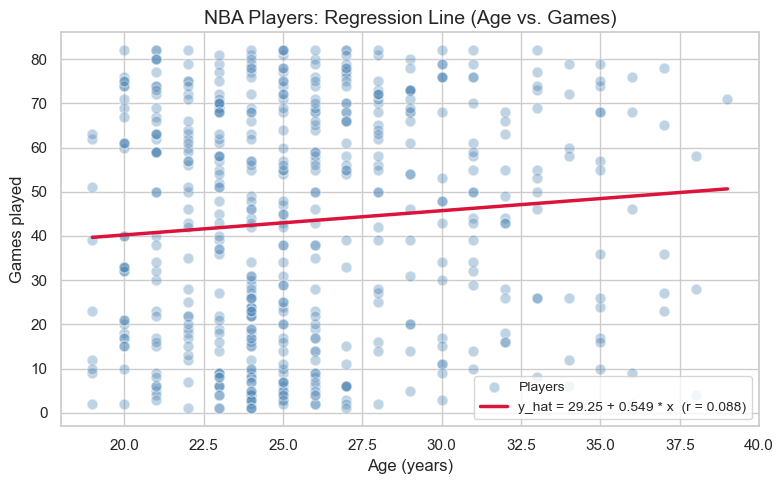

In [13]:
x_range = np.linspace(x.min(), x.max(), 200)
y_hat   = a + b * x_range

fig, ax = plt.subplots()

ax.scatter(x, y, alpha=0.35, color="steelblue",
           edgecolors="white", s=60, label="Players")
ax.plot(x_range, y_hat, color="crimson", linewidth=2.5,
        label=f"y_hat = {a:.2f} + {b:.3f} * x  (r = {r:.3f})")

ax.set_xlabel("Age (years)", fontsize=12)
ax.set_ylabel("Games played", fontsize=12)
ax.set_title("NBA Players: Regression Line (Age vs. Games)", fontsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 5.2.1 Interactive: Try Your Own Line

OpenStax emphasizes that the least-squares line is the line that makes the total squared error as small as possible.

Use the sliders below to choose your own slope and intercept. Compare your line to the best-fit line and watch the **SSE** (sum of squared errors).

- Smaller SSE = better fit
- The best-fit line should usually have one of the smallest SSE values

In [ ]:
show_interactive_line_tuner(
    x=x, y=y, a=a, b=b, x_range=x_range, y_hat=y_hat,
    x_label="Age (years)", y_label="Games played", money_yaxis=False,
)

**Question 5.1 (Code Practice — instructor solution).** The next code cell shows the completed slope interpretation.

In [15]:
# Instructor solution: interpret slope b in context
games_change_per_year = b
age_increase = 1
predicted_change = games_change_per_year * age_increase

print(f"For each +{age_increase} year of age, predicted games played change by {predicted_change:.4f}.")


For each +1 year of age, predicted games played change by 0.5486.


### 5.3. Making Predictions

One of the most useful things about the regression line is that we can plug in any **`Age`** to get a **predicted number of games played**. Use the slider below to explore predictions for different ages!

> ⚠️ **Important:** Predictions are only reliable **within the range of the data**. Predicting far outside this range — called **extrapolation** — can lead to unreliable results.

In [16]:
show_prediction_slider(
    x=x, y=y, a=a, b=b, x_range=x_range, y_hat=y_hat,
    x_label="Age (years)", y_label="Games played", money_yaxis=False,
    slider_description="Age (years):",
)

FloatSlider(value=25.7, description='Age (years):', layout=Layout(width='480px'), max=39.0, min=19.0, style=Sl…

Output()

**Question 5.2.** Use the slider to find the predicted games played for a player who is **28 years old**. Then verify your answer by completing the code cell below using the regression equation `a + b * x`. Do both answers match?

In [17]:
# Instructor solution: predict games for age 28 using a + b * x
age_input = 28
predicted_games = a + b * age_input

print(f"Predicted games for age {age_input}: {predicted_games:.2f}")


Predicted games for age 28: 44.61


*Your Answer Here (does your manual calculation match the slider?)*

---

## 6. Exploring Other Relationships (Sandbox)

We've seen a **weak linear link between age and games played**. The NBA dataset has many other numeric columns — points, salary, rebounds, assists, and more. How do other pairs compare?

In this sandbox section, you'll pick **any two numeric columns** and run your own regression analysis using the dropdowns below.

### 6.1. Choosing Variables

In [18]:
# First, let's remind ourselves of all available numeric columns
numeric_cols = nba_clean.select_dtypes(include="number").columns.tolist()
print("Available numeric columns:")
print(numeric_cols)

Available numeric columns:
['Salary Rank', 'Salary', 'Player Rank', 'Age', 'Games', 'Rebounds', 'Assists', 'Steals', 'Blocks', 'Turnovers', 'Points']


In [19]:
# Choose your x and y variables using the dropdowns, then click Run Regression
show_sandbox_regression(nba_clean)

Button(button_style='primary', description='Run Regression', style=ButtonStyle())

Output()

**Question 6.1.** Which pair of variables did you choose to explore? Before running the regression, what did you expect — a positive relationship, a negative relationship, or no relationship? Explain your intuition.

*Your Answer Here*

### 6.2. Running Your Own Regression

**Question 6.2.** What did you actually find? Report the correlation coefficient *r* for your chosen pair. Is the relationship stronger or weaker than the **`Age` vs `Games`** relationship from Section 5? Does the result match what you expected in Question 6.1?

*Your Answer Here*

---

## 7. Conclusion

In this notebook, we explored the core ideas of **Linear Regression and Correlation** using real NBA player data:

- A **scatter plot** is the essential first step for understanding the relationship between two numeric variables.
- The **correlation coefficient *r*** (between -1 and +1) measures how strongly and in what direction two variables are linearly related.
- The **regression line** `y_hat = a + b*x` is the best-fit line through the data, computed from *r*, the standard deviations, and the means of x and y.
- We can use the regression line to **predict** values of y for a given x — but only reliably within the observed range of the data (no extrapolation!).

These tools form the foundation for more advanced modeling in data science and statistics. Nice work! 🎉

**Want to explore further?** Try looking at whether `MIN` (minutes played) predicts `Points` better than any salary-related variable, or compare how correlations differ across player positions.

## 📋 Post-Notebook Reflection Form

Thank you for completing the notebook! We'd love to hear your thoughts so we can continue improving and creating content that supports your learning.

Please take a few minutes to fill out this short reflection form:

👉 **[Click here to fill out the Reflection Form](#)**

---

### 🧠 Why it matters:
Your feedback helps us understand:
- How clear and helpful the notebook was
- What you learned from the experience
- What topics you'd like to see in the future

This form is anonymous and should take less than 5 minutes to complete.

We appreciate your time and honest input! 💬

---

**Woohoo! You have completed this notebook! 🚀**